# 13.3 US Baby Names 1880–2010


## 1. Giới thiệu về bộ dữ liệu

**Nguồn gốc và Bối cảnh:**

Bộ dữ liệu này được cung cấp bởi **Cục An sinh Xã hội Hoa Kỳ (Social Security Administration - SSA)**. Nó chứa thông tin về tần suất của các tên được đặt cho trẻ sơ sinh, dựa trên đơn đăng ký thẻ An sinh Xã hội.

**Phạm vi:**

- **Thời gian:** Kéo dài 131 năm, từ 1880 đến 2010.

- **Quy mô:** Sau khi tổng hợp, bộ dữ liệu bao gồm hàng triệu bản ghi, cung cấp một cái nhìn toàn diện và chi tiết về lịch sử đặt tên tại Mỹ.

>Đây là một bộ dữ liệu "sạch", dễ tiếp cận, và cực kỳ lý tưởng cho việc thực hành phân tích dữ liệu theo chuỗi thời gian và khám phá các xu hướng xã hội.

In [1]:
import pandas as pd
names1880 = pd.read_csv("dataset/babynames/yob1880.txt",
                        names=["name", "sex", "births"])
names1880.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   name    2000 non-null   object
 1   sex     2000 non-null   object
 2   births  2000 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 47.0+ KB


**Cấu trúc Dữ liệu**

Dữ liệu gốc được chia thành các tệp văn bản (.txt) riêng lẻ cho mỗi năm, từ yob1880.txt đến yob2010.txt. Mỗi tệp chứa ba cột, không có tiêu đề:

<div align="center">
  <h3>Ý nghĩa các cột trong dataset tên em bé</h3>

  <table style="margin:auto; border-collapse:collapse;">
    <thead>
      <tr>
        <th style="padding:8px; text-align:center;">Cột</th>
        <th style="padding:8px; text-align:center;">Ý nghĩa</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td style="padding:8px; text-align:center;">name</td>
        <td style="padding:8px; text-align:center;">Tên em bé</td>
      </tr>
      <tr>
        <td style="padding:8px; text-align:center;">sex</td>
        <td style="padding:8px; text-align:center;">Giới tính (F = nữ, M = nam)</td>
      </tr>
      <tr>
        <td style="padding:8px; text-align:center;">births</td>
        <td style="padding:8px; text-align:center;">Số lượng trẻ sinh mang tên đó trong năm</td>
      </tr>
    </tbody>
  </table>
</div>

> Một điểm quan trọng cần lưu ý là để đảm bảo tính riêng tư, SSA chỉ công bố những tên có **ít nhất 5 lần xuất hiện** trong một năm nhất định cho một giới tính cụ thể.

## 2. Phân tích mô tả


### 2.1 Phân tích dữ liệu năm 1880

In [20]:
names1880.groupby("sex")["births"].sum()

sex
F     90993
M    110493
Name: births, dtype: int64

**Nhận xét:**
- Với năm 1880 tỷ lệ sinh giới tính Nam (110493) > giới tính nữ (90993). Tuy nhiên đây là tổng số các tên có ít nhất 5 lần xuất hiện, vì thế con số sẽ thấp hơn so với tổng ca sinh thực tế của năm đó.

### 2.2 Phân tích tổng số ca sinh trên toàn bộ dữ liệu

In [21]:
pieces = []
for year in range(1880, 2011):
    path = f"dataset/babynames/yob{year}.txt"
    frame = pd.read_csv(path, names=["name", "sex", "births"])

    frame["year"] = year
    pieces.append(frame)

names = pd.concat(pieces, ignore_index=True)
names

,name,sex,births,year
0,Mary,F,7065,1880
1,Anna,F,2604,1880
2,Emma,F,2003,1880
3,Elizabeth,F,1939,1880
4,Minnie,F,1746,1880
...,...,...,...,...
1690779,Zymaire,M,5,2010
1690780,Zyonne,M,5,2010
1690781,Zyquarius,M,5,2010
1690782,Zyran,M,5,2010


**Nhận xét:**

- Đối với dữ liệu hoàn chinh, thực hiện việc nhóm dữ liệu theo Năm sinh và giới tính để xem toàn bộ tổng số ca sinh 
- Có thể thấy rằng tổng số ca lên đến $1690784$ so với con số tổng trước đó giữa nam và nữ xuất hiện 5 lần là $201486$ (nhỏ gấp 8 lần)

In [22]:
# Sử dụng pivot_table để tổng hợp dữ liệu
total_births = names.pivot_table('births', index='year', columns='sex', aggfunc=sum)

# Hiển thị 5 dòng cuối cùng 
print("5 dòng cuối của DataFrame tạo bằng pivot_table:")
display(total_births.tail())

5 dòng cuối của DataFrame tạo bằng pivot_table:


C:\Users\luong\AppData\Local\Temp\ipykernel_18316\2147324069.py:2: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  total_births = names.pivot_table('births', index='year', columns='sex', aggfunc=sum)


sex,F,M
year,,
2006,1896468,2050234
2007,1916888,2069242
2008,1883645,2032310
2009,1827643,1973359
2010,1759010,1898382


**1) Số lượng trẻ sinh theo giới tính thay đổi như thế nào từ 1880–2010?**

C:\Users\luong\AppData\Local\Temp\ipykernel_18316\895505655.py:1: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  total_births = names.pivot_table("births", index="year",


<Axes: title={'center': 'Total births by sex and year'}, xlabel='year'>

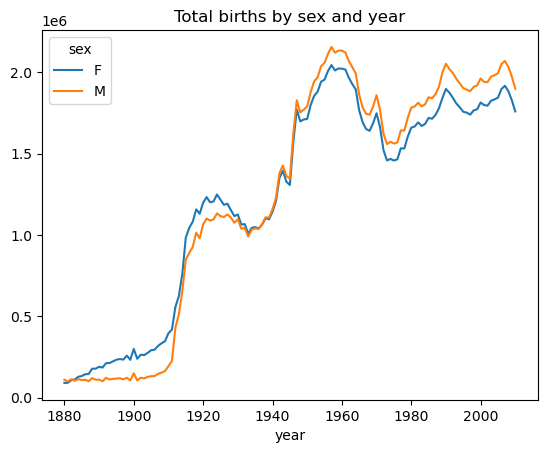

In [23]:
total_births = names.pivot_table("births", index="year",
                                 columns="sex", aggfunc=sum)
total_births.tail()
total_births.plot(title="Total births by sex and year")

**Nhận xét:**
- Trong khoảng 1880-2010, số lượng trẻ sinh theo giới tính nam có sự gia tăng trong 1880-1930, tuy nhiên từ năm 1930 trở đi xu hướng giảm đi so với giới tính nữ. 

**Các cột mốc nổi bật:**

- Với khoản 1920-1930 đây là giai đoạn sau Thế chiến I, cho nên làm dân số của Hoa Kỳ bùng nổ dân số
- Với khoảng 1940-1960 đây là giai đoạn sau Thế chiến II, sau sự kiện đó thế giới hòa bình khiến dân số của Hoa Kỳ gia tăng bùng nổ.

**2) Tên nào phổ biến nhất mỗi thập kỷ (top 10 theo năm hoặc giới)?**

In [24]:
def get_top1000(group):
    return group.sort_values("births", ascending=False)[:1000]
grouped = names.groupby(["year", "sex"])
top1000 = grouped.apply(get_top1000)
top1000.head()

C:\Users\luong\AppData\Local\Temp\ipykernel_18316\2738497238.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top1000 = grouped.apply(get_top1000)


name sex  births  year
year sex                               
1880 F   0       Mary   F    7065  1880
         1       Anna   F    2604  1880
         2       Emma   F    2003  1880
         3  Elizabeth   F    1939  1880
         4     Minnie   F    1746  1880

**Nhận xét:**
- Các cột index không phù hợp và chiếm nhiều không gian trong DataFrame, cần loại bỏ các index này.

In [25]:
top1000 = top1000.reset_index(drop=True)
top1000.head()

,name,sex,births,year
0,Mary,F,7065,1880
1,Anna,F,2604,1880
2,Emma,F,2003,1880
3,Elizabeth,F,1939,1880
4,Minnie,F,1746,1880


**Nhận xét:**
- Thực hiện lấy 1.000 tên phổ biến cho mỗi nhóm (năm và giới tính), việc lấy nhiều để khi discending lấy các tên xuất hiện nhiều nhất một cách chính xác. 

**3) Độ tập trung tên có thay đổi theo thời gian không (tên phổ biến chiếm bao nhiêu % tổng số sinh)?**

In [26]:
total_births = top1000.pivot_table("births", index="year",
                                   columns="name",
                                   aggfunc=sum)
year_totals = total_births.sum(axis=1)
subset = total_births[["John","Harry","Mary","Marilyn"]].fillna(0)
subset_pct = subset.div(year_totals, axis=0).mul(100)       # % theo năm cho từng tên
subset_total_pct = subset_pct.sum(axis=1)                   # % gộp 4 tên

topk_share = (total_births.apply(lambda s: s.sort_values(ascending=False)
                                             .head(10).sum(), axis=1)
              / year_totals * 100)

topk_share



C:\Users\luong\AppData\Local\Temp\ipykernel_18316\2259516713.py:1: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  total_births = top1000.pivot_table("births", index="year",


year
1880    26.775383
1881    25.679932
1882    24.890110
1883    23.787950
1884    22.975475
          ...    
2006     6.593956
2007     6.398473
2008     6.229628
2009     6.289913
2010     6.424692
Length: 131, dtype: float64

**Nhận xét:**
- 1880: ~26.78% → 4 tên này chiếm hơn 1/4 tổng số sinh.

- 2010: ~6.42% → chỉ còn khoảng 1/16 tổng số sinh.

- Mức tập trung giảm mạnh: giảm ~20.35 điểm % (từ 26.78 xuống 6.42), tương đương giảm ~76% so với ban đầu (6.42 / 26.78 ≈ 0.24).
>Điều này khẳng định: theo thời gian, thị hiếu đặt tên phân tán hơn, một vài tên “siêu phổ biến” không còn chiếm tỷ trọng lớn như trước.

## 3. Phân tích khám phá


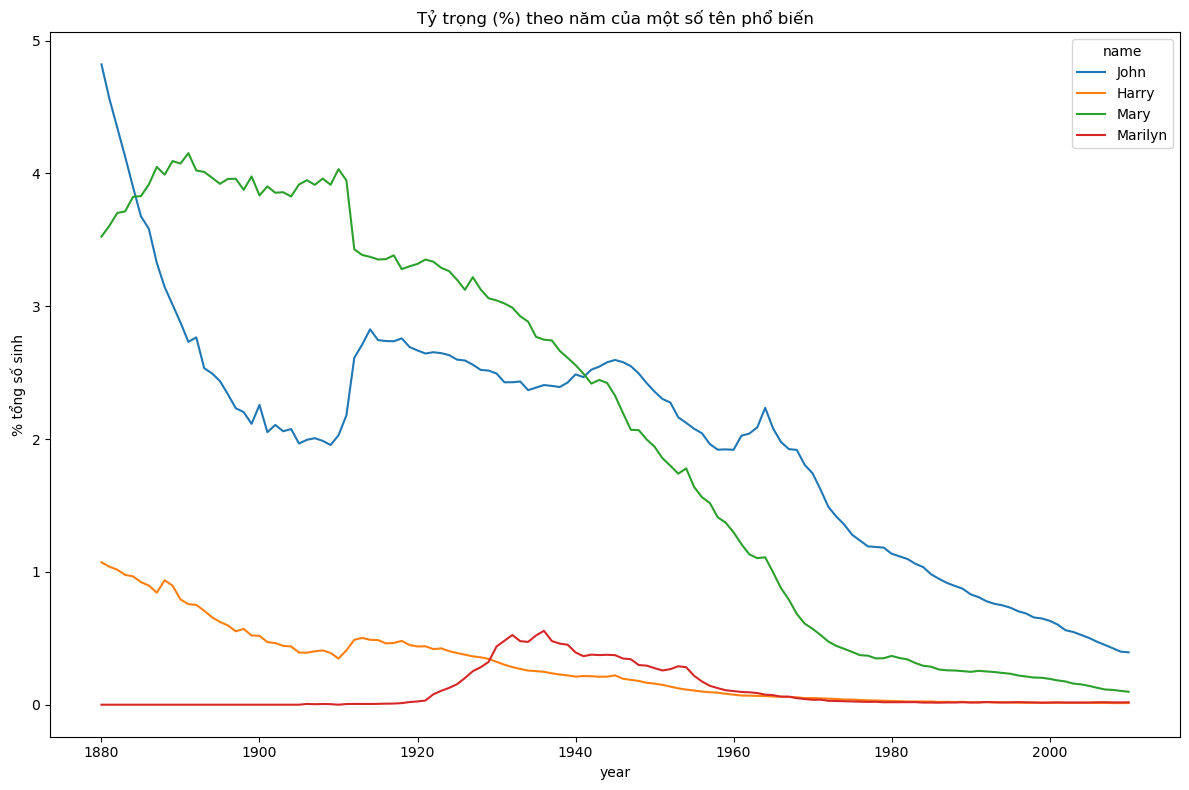

In [27]:
import matplotlib.pyplot as plt

# Pivot đã có: total_births (rows=year, cols=name, values=births)
year_totals = total_births.sum(axis=1)  # tổng số sinh mỗi năm (mọi tên, cả 2 giới)

# Chọn các tên cần theo dõi
subset = total_births[["John", "Harry", "Mary", "Marilyn"]].fillna(0)

# Tính % theo năm cho từng tên
subset_pct = subset.div(year_totals, axis=0).mul(100)

# Vẽ
ax = subset_pct.plot(figsize=(12, 8))
ax.set_ylabel("% tổng số sinh")
ax.set_title("Tỷ trọng (%) theo năm của một số tên phổ biến")
plt.tight_layout()
plt.show()



**Nhận xét:**

**Xu hướng chung:** Cả bốn đường đều đi giảm dần dài hạn. Điều này phản ánh hiện tượng “đa dạng hoá tên” theo thời gian: về sau có nhiều tên khác nhau hơn nên mỗi tên riêng lẻ chiếm tỷ trọng nhỏ hơn.

- John (xanh dương): Rất phổ biến cuối thế kỷ 19–đầu thế kỷ 20 (~2–4% tổng sinh), sau đó giảm đều qua nửa sau thế kỷ 20 đến nay (<1%). Đây là mẫu điển hình cho tên truyền thống nam giảm nhiệt theo thời gian.

- Mary (xanh lá): Là siêu phổ biến ở đầu thế kỷ 20 (~3.5–4% tổng sinh), nhưng lao dốc mạnh từ sau 1940–1970 và tiếp tục giảm về mức rất thấp sau 1990. Phản ánh sự dịch chuyển khỏi các tên kinh điển nữ.

- Harry (cam): Phổ biến vừa phải cuối thế kỷ 19, tụt dốc liên tục trong thế kỷ 20, về gần 0% sau 1970. (Tên chịu ảnh hưởng chu kỳ thời trang/đời sống văn hóa, nhưng nhìn chung không bùng nổ như John hay Mary.)

- Marilyn (đỏ): Gần như 0% trước 1920, tăng nhanh giai đoạn 1930–1950 rồi biến mất dần sau 1960. Đây là ví dụ rõ của “cú bùng nổ ngắn hạn” (gắn với văn hóa đại chúng) rồi thoái trào.

>Kết luận: Mức tập trung tên theo thời gian giảm—những tên “đỉnh” (John/Mary) từng chiếm vài phần trăm tổng sinh, nay chỉ còn phần nhỏ. Tên mới nổi (Marilyn) có thể tăng mạnh trong một–hai thập kỷ rồi rơi nhanh, cho thấy vòng đời thời trang của tên ngày càng ngắn.


# KẾT THÚC